# IMDb Movie Score Prediction: Updated Exploration Notebook

Main question:

> Can IMDb-style movie scores be predicted or explained using movie metadata and financial features?

This updated notebook mirrors the current `src/final_project_analysis.py` workflow. The main updates compared with the earlier exploration notebook are:

- all listed genres are converted into multi-hot `genre_*` columns and used in the models;
- `main_genre` is kept for easier EDA and cluster summaries, but not used as the only genre feature;
- `is_english` is added as a binary feature;
- detailed `language` and `country` categories are kept for EDA/profile summaries, but excluded from the model feature matrix;
- classification uses quantile-based low/medium/high score groups;
- K-Means is treated as exploratory, with elbow, silhouette, PCA visualization, and cluster profiles.

## 1. Imports and paths

Run this first. The path logic works whether this notebook is inside a `notebooks/` folder in the repo or run from the project root. It expects the dataset at `data/imdb_movies.csv`.

In [30]:
from pathlib import Path
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    silhouette_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

RANDOM_STATE = 42
KMEANS_N_CLUSTERS = 4

# Robust project-root detection.
try:
    NOTEBOOK_DIR = Path(__file__).resolve().parent
except NameError:
    NOTEBOOK_DIR = Path.cwd()

candidate_roots = [
    NOTEBOOK_DIR,
    NOTEBOOK_DIR.parent,
    Path.cwd(),
    Path.cwd().parent,
    Path("/mnt/data"),  # helpful when testing in ChatGPT sandbox
]

PROJECT_ROOT = None
for root in candidate_roots:
    if (root / "data" / "imdb_movies.csv").exists():
        PROJECT_ROOT = root
        DATA_PATH = root / "data" / "imdb_movies.csv"
        break
    if (root / "imdb_movies.csv").exists():
        PROJECT_ROOT = root
        DATA_PATH = root / "imdb_movies.csv"
        break

if PROJECT_ROOT is None:
    PROJECT_ROOT = NOTEBOOK_DIR
    DATA_PATH = PROJECT_ROOT / "data" / "imdb_movies.csv"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
FIGURE_DIR = OUTPUT_DIR / "figures"
OUTPUT_DIR.mkdir(exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)

Project root: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject
Data path: c:\Users\craig\Documents\School\Intro to Data Science\Final Project\DataScienceProject\data\imdb_movies.csv


## 2. Load the raw dataset

First we inspect the original CSV before cleaning. This helps document the original columns, shape, and basic structure.

In [31]:
raw_df = pd.read_csv(DATA_PATH)

print("Raw dataset shape:", raw_df.shape)
display(raw_df.head())
display(raw_df.info())

Raw dataset shape: (10178, 12)


,names,date_x,score,genre,overview,crew,orig_title,status,orig_lang,budget_x,revenue,country
0,Creed III,03/02/2023,73.0,"Drama, Action","After dominating the boxing world, Adonis Cree...","Michael B. Jordan, Adonis Creed, Tessa Thompso...",Creed III,Released,English,75000000.0,2.716167e+08,AU
1,Avatar: The Way of Water,12/15/2022,78.0,"Science Fiction, Adventure, Action",Set more than a decade after the events of the...,"Sam Worthington, Jake Sully, Zoe Saldaña, Neyt...",Avatar: The Way of Water,Released,English,460000000.0,2.316795e+09,AU
2,The Super Mario Bros. Movie,04/05/2023,76.0,"Animation, Adventure, Family, Fantasy, Comedy","While working underground to fix a water main,...","Chris Pratt, Mario (voice), Anya Taylor-Joy, P...",The Super Mario Bros. Movie,Released,English,100000000.0,7.244590e+08,AU
3,Mummies,01/05/2023,70.0,"Animation, Comedy, Family, Adventure, Fantasy","Through a series of unfortunate events, three ...","Óscar Barberán, Thut (voice), Ana Esther Albor...",Momias,Released,"Spanish, Castilian",12300000.0,3.420000e+07,AU
4,Supercell,03/17/2023,61.0,Action,Good-hearted teenager William always lived in ...,"Skeet Ulrich, Roy Cameron, Anne Heche, Dr Quin...",Supercell,Released,English,77000000.0,3.409420e+08,US


<class 'pandas.DataFrame'>
RangeIndex: 10178 entries, 0 to 10177
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   names       10178 non-null  str    
 1   date_x      10178 non-null  str    
 2   score       10178 non-null  float64
 3   genre       10093 non-null  str    
 4   overview    10178 non-null  str    
 5   crew        10122 non-null  str    
 6   orig_title  10178 non-null  str    
 7   status      10178 non-null  str    
 8   orig_lang   10178 non-null  str    
 9   budget_x    10178 non-null  float64
 10  revenue     10178 non-null  float64
 11  country     10178 non-null  str    
dtypes: float64(3), str(9)
memory usage: 954.3 KB


None

## 3. Basic raw-data checks

These checks help support the data quality/preprocessing discussion in the report.

In [32]:
raw_summary = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_rate": raw_df.isna().mean().round(4),
    "dtype": raw_df.dtypes.astype(str),
})

display(raw_summary)

budget_col = "budget_x" if "budget_x" in raw_df.columns else "budget"

print("Raw score summary:")
display(pd.to_numeric(raw_df["score"], errors="coerce").describe())

print("Zero budget rate:", round((pd.to_numeric(raw_df[budget_col], errors="coerce") == 0).mean(), 4))
print("Zero revenue rate:", round((pd.to_numeric(raw_df["revenue"], errors="coerce") == 0).mean(), 4))

,missing_count,missing_rate,dtype
names,0,0.0000,str
date_x,0,0.0000,str
score,0,0.0000,float64
genre,85,0.0084,str
overview,0,0.0000,str
crew,56,0.0055,str
orig_title,0,0.0000,str
status,0,0.0000,str
orig_lang,0,0.0000,str
budget_x,0,0.0000,float64


Raw score summary:


count    10178.000000
mean        63.497052
std         13.537012
min          0.000000
25%         59.000000
50%         65.000000
75%         71.000000
max        100.000000
Name: score, dtype: float64

Zero budget rate: 0.0
Zero revenue rate: 0.0072


## 4. Cleaning and feature engineering helpers

This section mirrors the current script. The biggest modeling change is that genre is now represented by many `genre_*` columns instead of only `main_genre`.

In [33]:
NUMERIC_MODEL_FEATURES = [
    "log_budget",
    "log_revenue",
    "log_profit_shifted",
    "roi_capped",
    "release_year",
    "is_english",
]

# Language is summarized by is_english. Country is kept for EDA/profile summaries,
# but excluded from the model feature matrix because the country column is not reliable enough.
CATEGORICAL_MODEL_FEATURES = []


def normalize_text(value: object) -> str:
    if pd.isna(value):
        return "Unknown"
    text = str(value).replace("\xa0", " ").strip()
    return text if text else "Unknown"


def group_rare_categories(df: pd.DataFrame, column: str, min_count: int = 50) -> pd.Series:
    counts = df[column].value_counts()
    common_values = counts[counts >= min_count].index
    return df[column].where(df[column].isin(common_values), "Other")


def get_genre_features(df: pd.DataFrame) -> list[str]:
    return [col for col in df.columns if col.startswith("genre_")]


def get_model_feature_lists(df: pd.DataFrame) -> tuple[list[str], list[str]]:
    numeric_features = NUMERIC_MODEL_FEATURES + get_genre_features(df)
    categorical_features = CATEGORICAL_MODEL_FEATURES
    return numeric_features, categorical_features


def make_preprocessor(numeric_features: list[str], categorical_features: list[str]) -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
        ]
    )

    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, numeric_features),
            ("categorical", categorical_pipeline, categorical_features),
        ]
    )

## 5. Clean and engineer features

Important engineered features:

- `profit = revenue - budget`
- `roi = profit / budget`
- `roi_capped`: ROI capped at the 1st and 99th percentiles to reduce extreme outliers
- `log_budget`, `log_revenue`: log transforms to reduce skew
- `log_profit_shifted`: shifted because profit can be negative
- `main_genre`: first listed genre, used for EDA/cluster summaries
- `genre_*`: multi-hot genre indicators, used for modeling
- `is_english`: binary feature for whether original language is English

In [34]:
df = raw_df.copy()

df = df.rename(
    columns={
        "names": "title",
        "date_x": "release_date",
        "budget_x": "budget",
        "orig_lang": "language",
    }
)

df["release_date"] = pd.to_datetime(df["release_date"], errors="coerce")
df["release_year"] = df["release_date"].dt.year

df["genre"] = df["genre"].apply(normalize_text)
df["genre"] = df["genre"].str.replace(", ", ",", regex=False)
df["main_genre"] = df["genre"].str.split(",").str[0].apply(normalize_text)

# Newer version: use all listed genres by creating multi-hot genre columns.
genre_dummies = (
    df["genre"]
    .str.get_dummies(sep=",")
    .rename(columns=lambda c: "genre_" + c.strip().replace(" ", "_"))
)
df = pd.concat([df, genre_dummies], axis=1)

df["language"] = df["language"].apply(normalize_text)
df["is_english"] = (df["language"].str.lower() == "english").astype(int)
df["country"] = df["country"].apply(normalize_text)
df["status"] = df["status"].apply(normalize_text)

for col in ["score", "budget", "revenue"]:
    df[col] = pd.to_numeric(df[col], errors="coerce")

df["profit"] = df["revenue"] - df["budget"]
df["roi"] = np.where(df["budget"] > 0, df["profit"] / df["budget"], np.nan)

roi_bounds = df["roi"].replace([np.inf, -np.inf], np.nan).quantile([0.01, 0.99])
df["roi_capped"] = df["roi"].clip(lower=roi_bounds.loc[0.01], upper=roi_bounds.loc[0.99])

df["log_budget"] = np.log1p(df["budget"].clip(lower=0))
df["log_revenue"] = np.log1p(df["revenue"].clip(lower=0))
df["log_profit_shifted"] = np.log1p((df["profit"] - df["profit"].min()).clip(lower=0))

cleaned = df[df["status"].eq("Released")].copy()
cleaned = cleaned.dropna(subset=["score", "budget", "revenue"])
cleaned = cleaned[
    (cleaned["score"] > 0)
    & (cleaned["budget"] >= 0)
    & (cleaned["revenue"] >= 0)
].copy()

for col in ["main_genre", "language", "country"]:
    cleaned[col] = group_rare_categories(cleaned, col, min_count=50)

numeric_features, categorical_features = get_model_feature_lists(cleaned)
model_features = numeric_features + categorical_features

print("Cleaned dataset shape:", cleaned.shape)
print("Number of genre feature columns:", len(get_genre_features(cleaned)))
print("Model feature count:", len(model_features))
print("First 20 model features:")
print(model_features[:20])

display(cleaned[["title", "score", "budget", "revenue", "profit", "roi_capped", "release_year", "main_genre", "language", "is_english", "country"]].head())

Cleaned dataset shape: (9967, 41)
Number of genre feature columns: 20
Model feature count: 26
First 20 model features:
['log_budget', 'log_revenue', 'log_profit_shifted', 'roi_capped', 'release_year', 'is_english', 'genre_Action', 'genre_Adventure', 'genre_Animation', 'genre_Comedy', 'genre_Crime', 'genre_Documentary', 'genre_Drama', 'genre_Family', 'genre_Fantasy', 'genre_History', 'genre_Horror', 'genre_Music', 'genre_Mystery', 'genre_Romance']


,title,score,budget,revenue,profit,roi_capped,release_year,main_genre,language,is_english,country
0,Creed III,73.0,75000000.0,2.716167e+08,1.966167e+08,2.621556,2023,Drama,English,1,AU
1,Avatar: The Way of Water,78.0,460000000.0,2.316795e+09,1.856795e+09,4.036511,2022,Science Fiction,English,1,AU
2,The Super Mario Bros. Movie,76.0,100000000.0,7.244590e+08,6.244590e+08,6.244590,2023,Animation,English,1,AU
3,Mummies,70.0,12300000.0,3.420000e+07,2.190000e+07,1.780488,2023,Animation,"Spanish, Castilian",0,AU
4,Supercell,61.0,77000000.0,3.409420e+08,2.639420e+08,3.427818,2023,Action,English,1,US


## 6. Data quality summary

This is the table that can be summarized in the report's preprocessing section.

In [35]:
raw_budget = pd.to_numeric(raw_df[budget_col], errors="coerce")
raw_revenue = pd.to_numeric(raw_df["revenue"], errors="coerce")
raw_score = pd.to_numeric(raw_df["score"], errors="coerce")

data_quality_summary = pd.DataFrame([{
    "original_rows": len(raw_df),
    "cleaned_rows": len(cleaned),
    "rows_removed": len(raw_df) - len(cleaned),
    "percent_rows_removed": round((len(raw_df) - len(cleaned)) / len(raw_df), 4),
    "missing_genre_count": int(raw_df["genre"].isna().sum()),
    "missing_genre_rate": round(float(raw_df["genre"].isna().mean()), 4),
    "missing_crew_count": int(raw_df["crew"].isna().sum()) if "crew" in raw_df.columns else None,
    "missing_crew_rate": round(float(raw_df["crew"].isna().mean()), 4) if "crew" in raw_df.columns else None,
    "zero_budget_count": int((raw_budget == 0).sum()),
    "zero_budget_rate": round(float((raw_budget == 0).mean()), 4),
    "zero_revenue_count": int((raw_revenue == 0).sum()),
    "zero_revenue_rate": round(float((raw_revenue == 0).mean()), 4),
    "score_min": float(raw_score.min()),
    "score_max": float(raw_score.max()),
    "score_mean": float(raw_score.mean()),
    "score_median": float(raw_score.median()),
}])

display(data_quality_summary.T)
data_quality_summary.to_csv(OUTPUT_DIR / "data_quality_summary.csv", index=False)
cleaned.to_csv(OUTPUT_DIR / "cleaned_movies.csv", index=False)

,0
original_rows,10178.000000
cleaned_rows,9967.000000
rows_removed,211.000000
percent_rows_removed,0.020700
missing_genre_count,85.000000
missing_genre_rate,0.008400
missing_crew_count,56.000000
missing_crew_rate,0.005500
zero_budget_count,0.000000
zero_budget_rate,0.000000


## 7. Show the updated feature design explicitly

This cell is included so it is obvious in the notebook that the newer modeling setup is being used.

In [36]:
feature_summary = pd.DataFrame({
    "feature_group": [
        "Base numeric/log features",
        "Binary language summary",
        "Multi-hot genre features",
        "Detailed categorical features used in model",
        "EDA/profile-only categorical fields",
    ],
    "included_columns": [
        ", ".join([f for f in NUMERIC_MODEL_FEATURES if f != "is_english"]),
        "is_english",
        f"{len(get_genre_features(cleaned))} columns: " + ", ".join(get_genre_features(cleaned)[:10]) + (" ..." if len(get_genre_features(cleaned)) > 10 else ""),
        str(CATEGORICAL_MODEL_FEATURES),
        "main_genre, language, country",
    ],
    "used_for_modeling": [True, True, True, bool(CATEGORICAL_MODEL_FEATURES), False],
})

display(feature_summary)

,feature_group,included_columns,used_for_modeling
0,Base numeric/log features,"log_budget, log_revenue, log_profit_shifted, r...",True
1,Binary language summary,is_english,True
2,Multi-hot genre features,"20 columns: genre_Action, genre_Adventure, gen...",True
3,Detailed categorical features used in model,[],False
4,EDA/profile-only categorical fields,"main_genre, language, country",False


## 8. EDA: score distribution

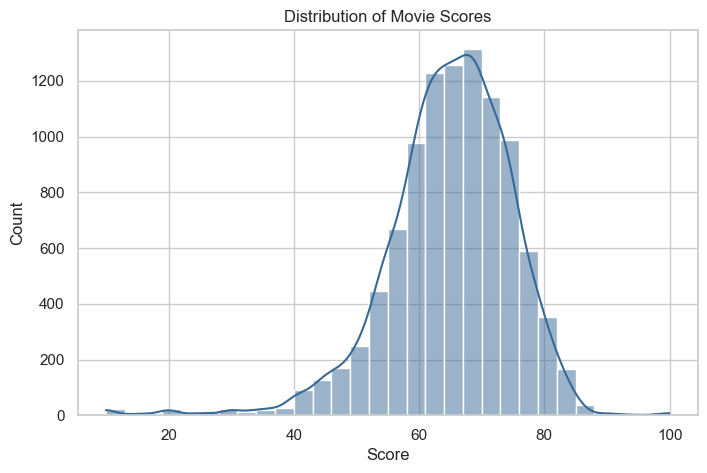

count    9967.000000
mean       64.841276
std         9.998028
min        10.000000
25%        60.000000
50%        66.000000
75%        72.000000
max       100.000000
Name: score, dtype: float64


In [37]:
plt.figure(figsize=(8, 5))
sns.histplot(cleaned["score"], bins=30, kde=True, color="#376996")
plt.title("Distribution of Movie Scores")
plt.xlabel("Score")
plt.show()

print(cleaned["score"].describe())

## 9. EDA: raw vs log-transformed financial variables

The raw financial features are extremely skewed, so the models use log-transformed versions.

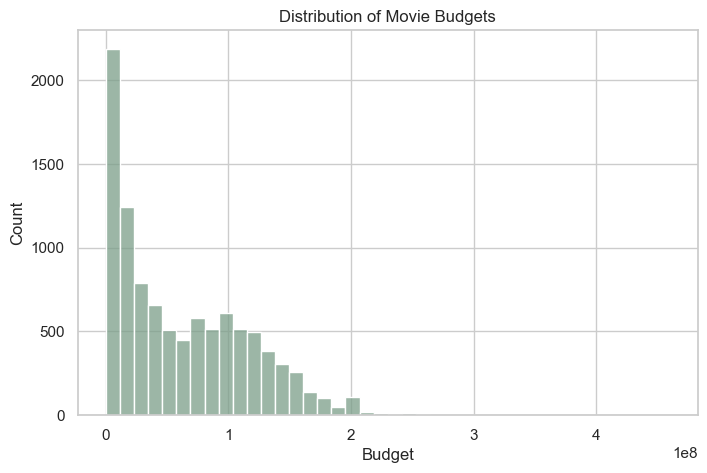

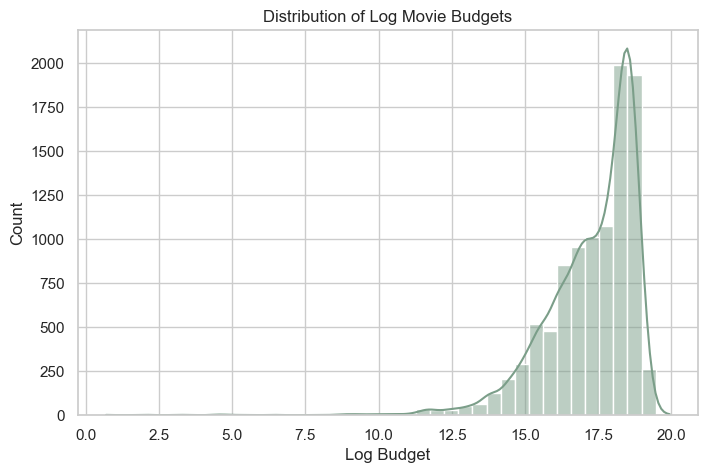

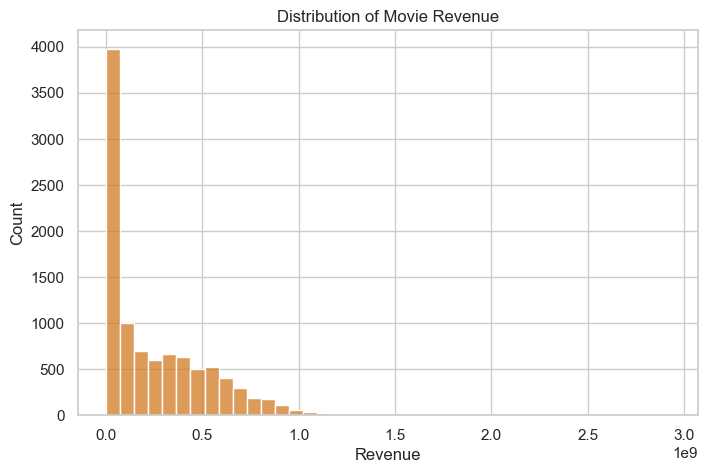

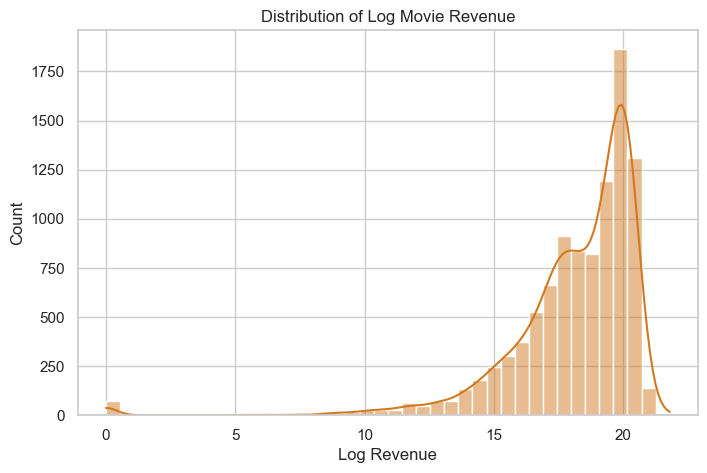

In [38]:
plt.figure(figsize=(8, 5))
sns.histplot(cleaned["budget"], bins=40, color="#7B9E89")
plt.title("Distribution of Movie Budgets")
plt.xlabel("Budget")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(cleaned["log_budget"], bins=40, kde=True, color="#7B9E89")
plt.title("Distribution of Log Movie Budgets")
plt.xlabel("Log Budget")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(cleaned["revenue"], bins=40, color="#D17A22")
plt.title("Distribution of Movie Revenue")
plt.xlabel("Revenue")
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(cleaned["log_revenue"], bins=40, kde=True, color="#D17A22")
plt.title("Distribution of Log Movie Revenue")
plt.xlabel("Log Revenue")
plt.show()

## 10. EDA: budget/revenue vs score

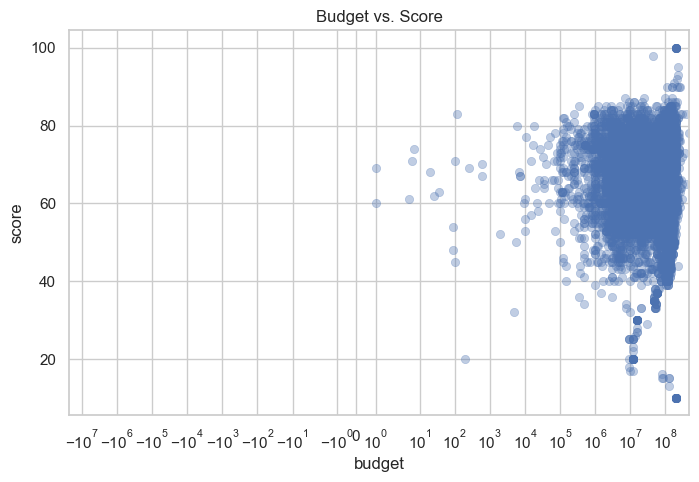

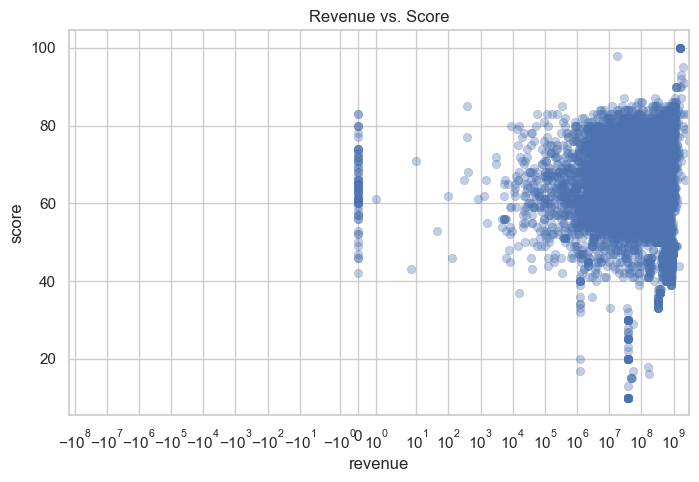

In [39]:
plt.figure(figsize=(8, 5))
sns.scatterplot(data=cleaned, x="budget", y="score", alpha=0.35, edgecolor=None)
plt.xscale("symlog")
plt.title("Budget vs. Score")
plt.show()

plt.figure(figsize=(8, 5))
sns.scatterplot(data=cleaned, x="revenue", y="score", alpha=0.35, edgecolor=None)
plt.xscale("symlog")
plt.title("Revenue vs. Score")
plt.show()

## 11. EDA: score by genre, language, and country

These are for interpretation only. The model no longer uses `main_genre`, detailed `language`, or `country` directly.

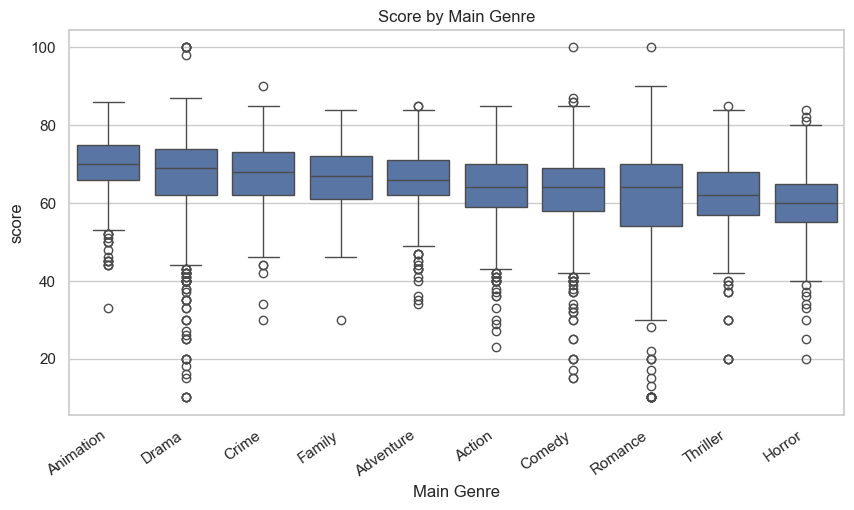

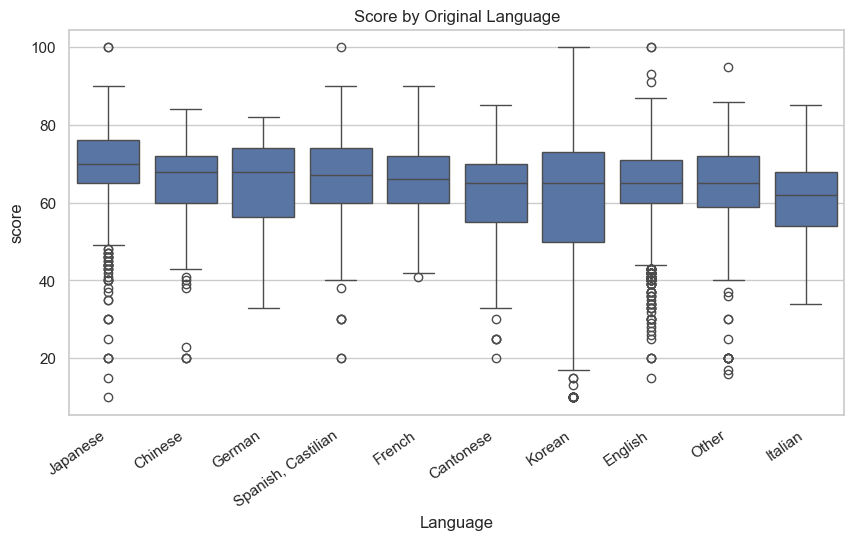

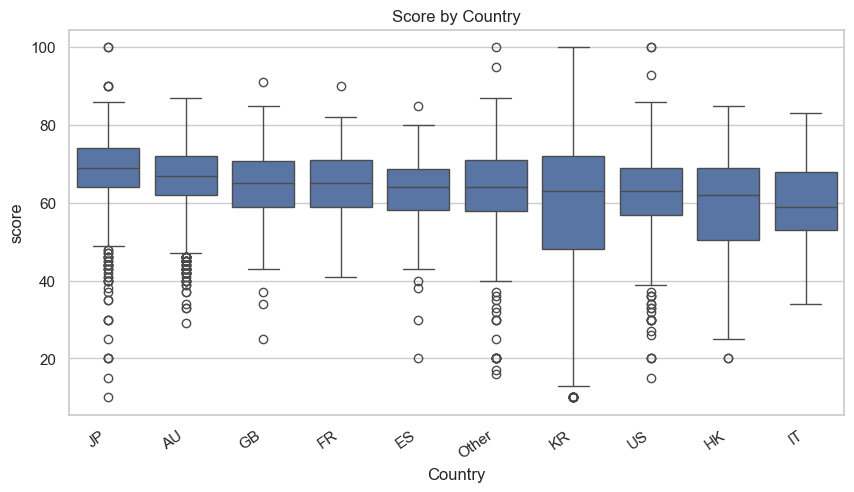

In [40]:
for col, title in [
    ("main_genre", "Score by Main Genre"),
    ("language", "Score by Original Language"),
    ("country", "Score by Country"),
]:
    top_values = cleaned[col].value_counts().head(10).index
    subset = cleaned[cleaned[col].isin(top_values)].copy()
    order = subset.groupby(col)["score"].median().sort_values(ascending=False).index

    plt.figure(figsize=(10, 5))
    sns.boxplot(data=subset, x=col, y="score", order=order)
    plt.title(title)
    plt.xlabel(col.replace("_", " ").title())
    plt.xticks(rotation=35, ha="right")
    plt.show()

## 12. EDA: correlation heatmap

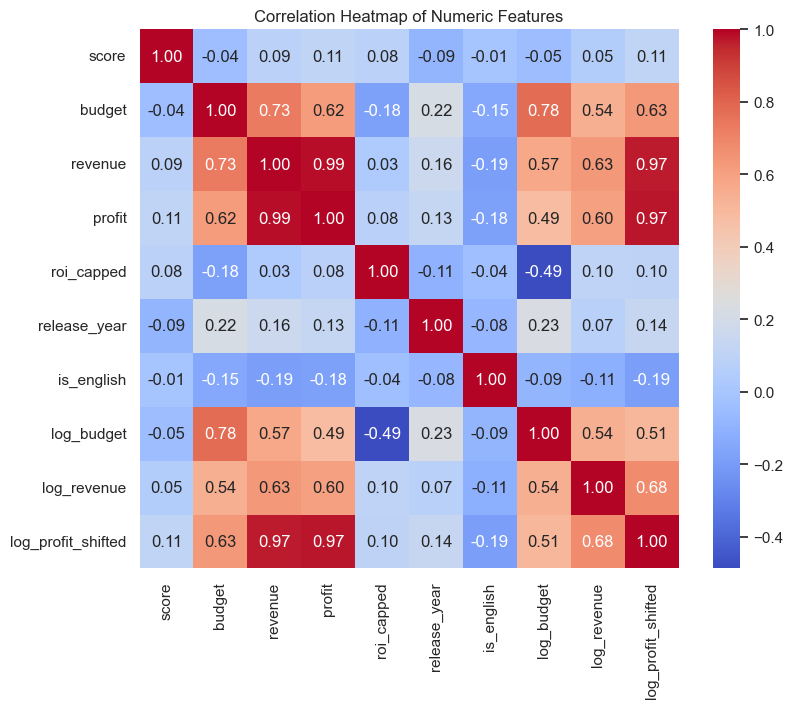

In [41]:
numeric_corr_cols = [
    "score",
    "budget",
    "revenue",
    "profit",
    "roi_capped",
    "release_year",
    "is_english",
    "log_budget",
    "log_revenue",
    "log_profit_shifted",
]

plt.figure(figsize=(9, 7))
corr = cleaned[numeric_corr_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Heatmap of Numeric Features")
plt.show()

## 13. Modeling helper functions

In [42]:
def regression_metrics(y_true: pd.Series, preds: np.ndarray, model_name: str) -> dict[str, float]:
    return {
        "model": model_name,
        "rmse": float(np.sqrt(mean_squared_error(y_true, preds))),
        "mae": float(mean_absolute_error(y_true, preds)),
        "r2": float(r2_score(y_true, preds)),
    }


def classification_metrics(y_true: pd.Series, preds: np.ndarray, model_name: str, category_distribution: dict[str, float]) -> dict[str, float]:
    return {
        "model": model_name,
        "accuracy": float(accuracy_score(y_true, preds)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, preds)),
        "precision_macro": float(precision_score(y_true, preds, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, preds, average="macro", zero_division=0)),
        "f1_macro": float(f1_score(y_true, preds, average="macro", zero_division=0)),
        "precision_weighted": float(precision_score(y_true, preds, average="weighted", zero_division=0)),
        "recall_weighted": float(recall_score(y_true, preds, average="weighted", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, preds, average="weighted", zero_division=0)),
        "low_rate": float(category_distribution.get("low", 0)),
        "medium_rate": float(category_distribution.get("medium", 0)),
        "high_rate": float(category_distribution.get("high", 0)),
    }

## 14. Regression Model 0: mean score baseline

In [43]:
y = cleaned["score"]
y_train, y_test = train_test_split(y, test_size=0.2, random_state=RANDOM_STATE)

train_mean = y_train.mean()
mean_prediction = np.full(shape=len(y_test), fill_value=train_mean)

mean_baseline_results = regression_metrics(y_test, mean_prediction, "Mean score baseline")
mean_baseline_results

{'model': 'Mean score baseline',
 'rmse': 10.329463868315067,
 'mae': 7.717587165107513,
 'r2': -0.0005169144241685686}

## 15. Regression Model 1: simple budget/revenue linear regression baseline

In [44]:
X = cleaned[["budget", "revenue"]]
y = cleaned["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

baseline_regression_model = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("regressor", LinearRegression()),
    ]
)

baseline_regression_model.fit(X_train, y_train)
baseline_preds = baseline_regression_model.predict(X_test)

baseline_regression_results = regression_metrics(y_test, baseline_preds, "Baseline linear regression")
baseline_regression_results

{'model': 'Baseline linear regression',
 'rmse': 10.12175488797592,
 'mae': 7.547620941370385,
 'r2': 0.03931611538501267}

## 16. Regression Model 2: improved linear regression

This is the updated model using engineered numeric features, `is_english`, and all multi-hot genre columns.

In [45]:
numeric_features, categorical_features = get_model_feature_lists(cleaned)
X = cleaned[numeric_features + categorical_features]
y = cleaned["score"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

improved_model = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(numeric_features, categorical_features)),
        ("regressor", LinearRegression()),
    ]
)

improved_model.fit(X_train, y_train)
improved_preds = improved_model.predict(X_test)

improved_regression_results = regression_metrics(y_test, improved_preds, "Improved linear regression")
improved_regression_results

{'model': 'Improved linear regression',
 'rmse': 9.307343871144436,
 'mae': 6.762578661756763,
 'r2': 0.18769263131818525}

## 17. Regression results summary

In [46]:
regression_results = pd.DataFrame([
    mean_baseline_results,
    baseline_regression_results,
    improved_regression_results,
])

display(regression_results)
regression_results.to_csv(OUTPUT_DIR / "regression_results.csv", index=False)

,model,rmse,mae,r2
0,Mean score baseline,10.329464,7.717587,-0.000517
1,Baseline linear regression,10.121755,7.547621,0.039316
2,Improved linear regression,9.307344,6.762579,0.187693


## 18. Regression coefficients

Because all model features are numeric after preprocessing, the coefficients can help explain which engineered variables and genres push predictions up or down most strongly. Coefficients should still be interpreted carefully because this is not a causal model.

In [47]:
preprocessor = improved_model.named_steps["preprocessor"]
regressor = improved_model.named_steps["regressor"]

feature_names = preprocessor.get_feature_names_out()
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": regressor.coef_,
    "absolute_coefficient": np.abs(regressor.coef_),
}).sort_values("absolute_coefficient", ascending=False)

display(coef_df.head(20))
coef_df.to_csv(OUTPUT_DIR / "regression_coefficients.csv", index=False)
coef_df.head(20).to_csv(OUTPUT_DIR / "top_regression_coefficients.csv", index=False)

,feature,coefficient,absolute_coefficient
8,numeric__genre_Animation,2.307857,2.307857
12,numeric__genre_Drama,1.907716,1.907716
2,numeric__log_profit_shifted,1.702480,1.702480
0,numeric__log_budget,-1.468892,1.468892
16,numeric__genre_Horror,-1.210349,1.210349
4,numeric__release_year,-0.726211,0.726211
11,numeric__genre_Documentary,0.682444,0.682444
15,numeric__genre_History,0.643899,0.643899
17,numeric__genre_Music,0.627668,0.627668
23,numeric__genre_Unknown,-0.599441,0.599441


## 19. Classification target: score quantile categories

The classification task converts score into roughly balanced low/medium/high categories using quantile cutoffs.

In [48]:
def add_score_category(df: pd.DataFrame, save_cutoffs: bool = False) -> pd.DataFrame:
    data = df.copy()
    _, bin_edges = pd.qcut(data["score"], q=3, retbins=True, duplicates="drop")
    labels = ["low", "medium", "high"][: len(bin_edges) - 1]

    data["score_category"] = pd.cut(
        data["score"],
        bins=bin_edges,
        labels=labels,
        include_lowest=True,
    )
    data = data.dropna(subset=["score_category"])

    if save_cutoffs:
        cutoff_rows = []
        for i, label in enumerate(labels):
            cutoff_rows.append({
                "category": label,
                "score_lower_bound": float(bin_edges[i]),
                "score_upper_bound": float(bin_edges[i + 1]),
            })
        pd.DataFrame(cutoff_rows).to_csv(OUTPUT_DIR / "score_category_cutoffs.csv", index=False)

    return data

classification_data = add_score_category(cleaned, save_cutoffs=True)

display(classification_data["score_category"].value_counts(normalize=True).rename("rate"))
display(pd.read_csv(OUTPUT_DIR / "score_category_cutoffs.csv"))

score_category
low       0.367713
high      0.330591
medium    0.301696
Name: rate, dtype: float64

,category,score_lower_bound,score_upper_bound
0,low,10.0,62.0
1,medium,62.0,69.0
2,high,69.0,100.0


## 20. Classification baseline: majority class

In [49]:
y = classification_data["score_category"].astype(str)
y_train, y_test = train_test_split(
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

majority_class = y_train.mode()[0]
majority_preds = np.full(shape=len(y_test), fill_value=majority_class)
category_distribution = y.value_counts(normalize=True).to_dict()

classification_baseline_results = classification_metrics(
    y_test,
    majority_preds,
    "Majority class baseline: score category",
    category_distribution,
)
classification_baseline_results

{'model': 'Majority class baseline: score category',
 'accuracy': 0.3676028084252758,
 'balanced_accuracy': 0.3333333333333333,
 'precision_macro': 0.12253426947509194,
 'recall_macro': 0.3333333333333333,
 'f1_macro': 0.17919569734751253,
 'precision_weighted': 0.13513182476215005,
 'recall_weighted': 0.3676028084252758,
 'f1_weighted': 0.1976185248080141,
 'low_rate': 0.3677134543995184,
 'medium_rate': 0.3016955954650346,
 'high_rate': 0.330590950135447}

## 21. Logistic regression classification model

This uses the same updated feature matrix as the improved regression model.

In [50]:
numeric_features, categorical_features = get_model_feature_lists(classification_data)
X = classification_data[numeric_features + categorical_features]
y = classification_data["score_category"].astype(str)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y,
)

classification_pipeline = Pipeline(
    steps=[
        ("preprocessor", make_preprocessor(numeric_features, categorical_features)),
        ("classifier", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE,
        )),
    ]
)

classification_pipeline.fit(X_train, y_train)
classification_preds = classification_pipeline.predict(X_test)

classification_model_results = classification_metrics(
    y_test,
    classification_preds,
    "Logistic regression classification: score quantile category",
    category_distribution,
)
classification_model_results

{'model': 'Logistic regression classification: score quantile category',
 'accuracy': 0.5030090270812437,
 'balanced_accuracy': 0.4916412883030412,
 'precision_macro': 0.481211317418214,
 'recall_macro': 0.4916412883030412,
 'f1_macro': 0.48086039060818636,
 'precision_weighted': 0.4865304990378487,
 'recall_weighted': 0.5030090270812437,
 'f1_weighted': 0.48950024056220565,
 'low_rate': 0.3677134543995184,
 'medium_rate': 0.3016955954650346,
 'high_rate': 0.330590950135447}

## 22. Classification results summary

In [51]:
classification_results = pd.DataFrame([
    classification_baseline_results,
    classification_model_results,
])

display(classification_results)
classification_results.to_csv(OUTPUT_DIR / "classification_results.csv", index=False)

model_results = pd.concat([regression_results, classification_results], ignore_index=True, sort=False)
display(model_results)
model_results.to_csv(OUTPUT_DIR / "model_results.csv", index=False)

,model,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,low_rate,medium_rate,high_rate
0,Majority class baseline: score category,0.367603,0.333333,0.122534,0.333333,0.179196,0.135132,0.367603,0.197619,0.367713,0.301696,0.330591
1,Logistic regression classification: score quan...,0.503009,0.491641,0.481211,0.491641,0.480860,0.486530,0.503009,0.489500,0.367713,0.301696,0.330591


,model,rmse,mae,r2,accuracy,balanced_accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,low_rate,medium_rate,high_rate
0,Mean score baseline,10.329464,7.717587,-0.000517,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Baseline linear regression,10.121755,7.547621,0.039316,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Improved linear regression,9.307344,6.762579,0.187693,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Majority class baseline: score category,NaN,NaN,NaN,0.367603,0.333333,0.122534,0.333333,0.179196,0.135132,0.367603,0.197619,0.367713,0.301696,0.330591
4,Logistic regression classification: score quan...,NaN,NaN,NaN,0.503009,0.491641,0.481211,0.491641,0.480860,0.486530,0.503009,0.489500,0.367713,0.301696,0.330591


## 23. Confusion matrix and classification error analysis

Predicted,low,medium,high
Actual,,,
low,448,138,147
medium,248,150,204
high,136,118,405


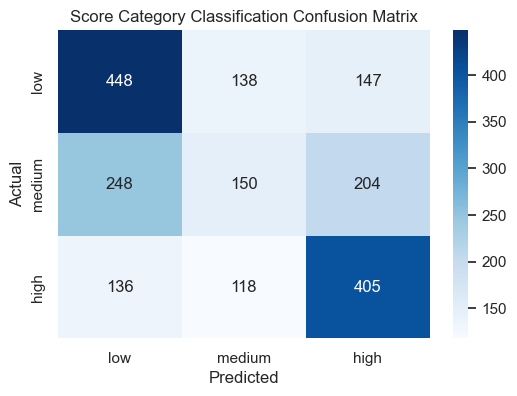

,actual_count,predicted_count,correct_predictions,recall,precision
low,733,832,448,0.6112,0.5385
medium,602,406,150,0.2492,0.3695
high,659,756,405,0.6146,0.5357


In [52]:
labels = ["low", "medium", "high"]
confusion = pd.crosstab(
    y_test,
    classification_preds,
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False,
).reindex(index=labels, columns=labels, fill_value=0)

display(confusion)

plt.figure(figsize=(6, 4))
sns.heatmap(confusion, annot=True, fmt="d", cmap="Blues")
plt.title("Score Category Classification Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

actual_counts = confusion.sum(axis=1)
predicted_counts = confusion.sum(axis=0)
correct_counts = pd.Series(np.diag(confusion), index=labels)

error_analysis = pd.DataFrame({
    "actual_count": actual_counts,
    "predicted_count": predicted_counts,
    "correct_predictions": correct_counts,
    "recall": correct_counts / actual_counts,
    "precision": correct_counts / predicted_counts.replace(0, np.nan),
}).round(4)

display(error_analysis)
error_analysis.to_csv(OUTPUT_DIR / "classification_error_analysis.csv", index_label="score_category")

## 24. K-Means elbow plot

K-Means is exploratory here. The elbow plot helps check whether there is a clear number of natural clusters.

,k,inertia
0,2,239677.374907
1,3,225635.093859
2,4,215006.993177
3,5,204255.753929
4,6,194837.280554
5,7,185759.957300
6,8,177863.818673
7,9,167841.661580
8,10,159194.186713


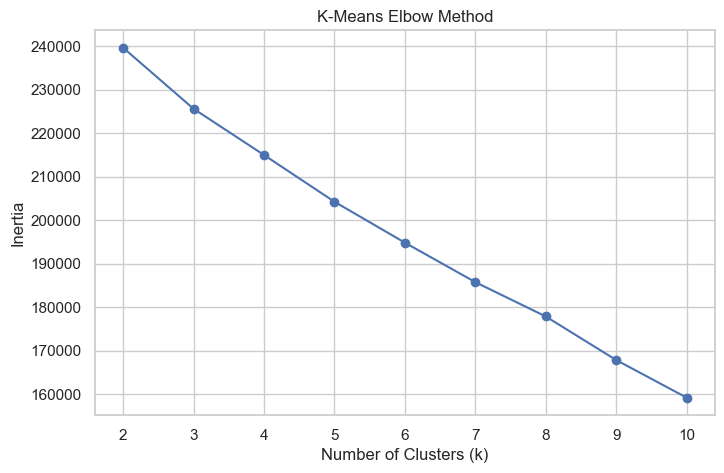

In [53]:
numeric_features, categorical_features = get_model_feature_lists(cleaned)
features = numeric_features + categorical_features

preprocessor = make_preprocessor(numeric_features, categorical_features)
X_processed = preprocessor.fit_transform(cleaned[features])

inertias = []
k_values = range(2, 11)
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    kmeans.fit(X_processed)
    inertias.append(kmeans.inertia_)

elbow_df = pd.DataFrame({"k": list(k_values), "inertia": inertias})
display(elbow_df)

plt.figure(figsize=(8, 5))
plt.plot(list(k_values), inertias, marker="o")
plt.title("K-Means Elbow Method")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.show()

## 25. K-Means silhouette scores

These scores help show why clustering is useful as a descriptive/exploratory tool, but not a perfect separation of movie types.

,k,silhouette_score
0,2,0.097635
1,3,0.094576
2,4,0.105633
3,5,0.116715
4,6,0.123605
5,7,0.129784
6,8,0.126155
7,9,0.153935
8,10,0.149982


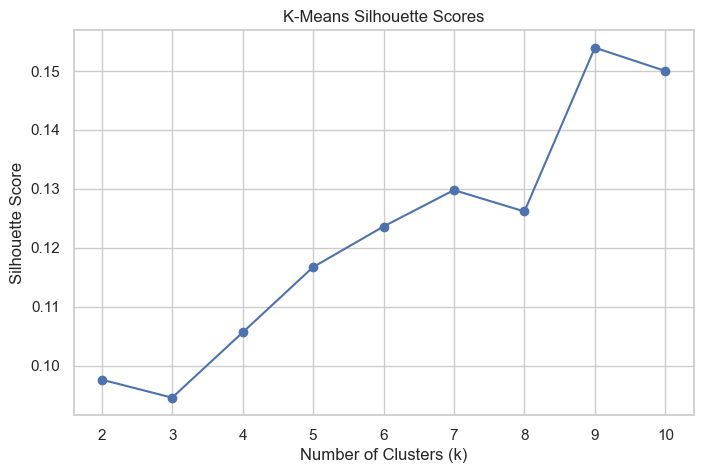

In [54]:
silhouette_rows = []
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=20)
    labels_k = kmeans.fit_predict(X_processed)
    silhouette_rows.append({
        "k": k,
        "silhouette_score": silhouette_score(X_processed, labels_k, sample_size=min(2000, X_processed.shape[0]), random_state=RANDOM_STATE),
    })

silhouette_df = pd.DataFrame(silhouette_rows)
display(silhouette_df)

plt.figure(figsize=(8, 5))
plt.plot(silhouette_df["k"], silhouette_df["silhouette_score"], marker="o")
plt.title("K-Means Silhouette Scores")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.show()

## 26. K-Means clustering + PCA visualization

We keep `k = 4` for interpretability. Even if larger k values slightly improve silhouette score, the PCA plot and cluster profiles are easier to explain with four broad groups.

PCA explained variance ratio: [0.10991278 0.07752066]


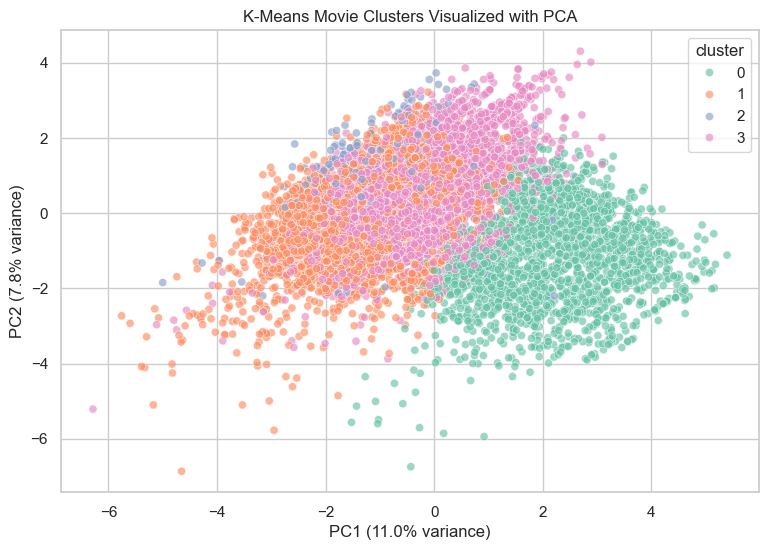

In [55]:
kmeans = KMeans(n_clusters=KMEANS_N_CLUSTERS, random_state=RANDOM_STATE, n_init=20)
cluster_labels = kmeans.fit_predict(X_processed)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
components = pca.fit_transform(X_processed)

clustered = cleaned.copy()
clustered["cluster"] = cluster_labels
clustered["pca_1"] = components[:, 0]
clustered["pca_2"] = components[:, 1]

print("PCA explained variance ratio:", pca.explained_variance_ratio_)

plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=clustered,
    x="pca_1",
    y="pca_2",
    hue="cluster",
    palette="Set2",
    alpha=0.65,
    s=35,
)
plt.title("K-Means Movie Clusters Visualized with PCA")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]:.1%} variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]:.1%} variance)")
plt.show()

## 27. Cluster profiles

These profiles are the main useful clustering output. The goal is not to claim perfect clusters, but to describe broad groups of similar movies.

In [56]:
cluster_profile = (
    clustered.groupby("cluster")
    .agg(
        movie_count=("title", "count"),
        avg_score=("score", "mean"),
        median_budget=("budget", "median"),
        median_revenue=("revenue", "median"),
        median_profit=("profit", "median"),
        median_roi=("roi", "median"),
        median_year=("release_year", "median"),
        top_genre=("main_genre", lambda s: s.value_counts().index[0]),
        top_language=("language", lambda s: s.value_counts().index[0]),
    )
    .round(3)
    .reset_index()
)

display(cluster_profile)
cluster_profile.to_csv(OUTPUT_DIR / "cluster_profiles.csv", index=False)

clustered[[
    "title",
    "score",
    "budget",
    "revenue",
    "profit",
    "main_genre",
    "language",
    "is_english",
    "country",
    "cluster",
]].to_csv(OUTPUT_DIR / "movies_with_clusters.csv", index=False)

,cluster,movie_count,avg_score,median_budget,median_revenue,median_profit,median_roi,median_year,top_genre,top_language
0,0,2310,66.953,88450000.0,329856760.8,222875665.9,2.686,2012.0,Animation,English
1,1,3575,62.738,27000000.0,61416888.0,38493064.0,1.787,2013.0,Action,English
2,2,279,69.814,38000000.0,81600000.0,40100000.0,1.804,2009.0,Drama,English
3,3,3803,65.171,51270000.0,180591246.6,125726374.4,2.898,2013.0,Drama,English


## 28. Final takeaway 

In [57]:
print("Main regression takeaway:")
print(regression_results.to_string(index=False))

print("\nMain classification takeaway:")
print(classification_results[["model", "accuracy", "balanced_accuracy", "f1_macro", "f1_weighted"]].to_string(index=False))

print("\nClustering takeaway:")
print("K-Means produced broad, interpretable movie groups, but elbow/silhouette/PCA suggest the groups overlap and should be treated as exploratory.")
print(cluster_profile.to_string(index=False))

Main regression takeaway:
                     model      rmse      mae        r2
       Mean score baseline 10.329464 7.717587 -0.000517
Baseline linear regression 10.121755 7.547621  0.039316
Improved linear regression  9.307344 6.762579  0.187693

Main classification takeaway:
                                                      model  accuracy  balanced_accuracy  f1_macro  f1_weighted
                    Majority class baseline: score category  0.367603           0.333333  0.179196     0.197619
Logistic regression classification: score quantile category  0.503009           0.491641  0.480860     0.489500

Clustering takeaway:
K-Means produced broad, interpretable movie groups, but elbow/silhouette/PCA suggest the groups overlap and should be treated as exploratory.
 cluster  movie_count  avg_score  median_budget  median_revenue  median_profit  median_roi  median_year top_genre top_language
       0         2310     66.953     88450000.0     329856760.8    222875665.9       2.686  